In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from plots_utils import *


### Ground Truth processing

In [2]:
table = pd.read_csv("important_cytokines_celltypes.csv")
table = table.map(lambda x: "NKS" if x == "NK" else x)
table = table.rename(columns={'IL12A, IL12B': 'IL12A'})

# Mapping of ccc_network names to ground names is required.

dct_ct = {"CD4 Memory": 'CD4_Memory_T_cell', 
"NK" : "NK",
"pDC" : "pDC",
"B Intermediate/Memory" : "Intermediate_B_cell",
"CD8 Memory" : "CD8_Memory_T_cell",
"cDC" : "cDC",
"NKT" : "NKT", 
"NKS" : "NK",
'NK CD56bright' : "NK_CD56hi",
"MAIT" : "MAIT", 
"Plasmablast" : "Plasmablast",
"CD16 Mono" : "CD16_Mono",
"HSPC" : "HSPC",
"CD14 Mono" : "CD14_Mono",
'ILC' : "ILC", 
'Treg' : "Treg", 
'CD8 Naive' : "CD8_Naive_T_cell",
'B Naive' : "Naive_B_cell",
'CD4 Naive': "CD4_Naive_T_cell"
}

gt = pd.read_csv("./outputs/human_cytokine_dict_mini.csv")

#print (gt["celltype"].unique(), "\n", gt.columns, "\n ", gt["cytokine"].unique())

In [3]:
cytokine_dct = pd.read_excel("cytokine_info.xlsx")
cyto_dct = cytokine_dct[["name", "gene"]].drop_duplicates()
cyto_dct = cyto_dct.map(lambda x: 'IL12A, IL12B' if x == 'IL12A' else x)
mapping = cyto_dct.set_index('name')['gene']

gt['cytokine'] = gt['cytokine'].map(mapping).fillna(gt['cytokine'])

In [4]:

grn_full_list = {}
main_path = "./Saved_results/effects_" #effects_dictys/" #hummus, dictys, scenic, scenic_plus

for grn in ["dictys", "hummus", "scenic", "scenic_plus"]:
    
    print (grn)
    path = main_path + grn + "/"

    full_dict = {}
    for c in table.columns: 
    
        seed = c
        if c in ["IFNL3"]:
            continue
        direct_effect = pd.read_csv(path + seed + "_direct_effect.csv", index_col = 0)
        indirect_effect = pd.read_csv(path + seed + "_indirect_effect.csv", header=[0, 1],index_col=0)
    
        cell__types = table[c].dropna().tolist()
        
        gt_filtered = gt[gt["cytokine"] == c].reset_index(drop = True)
        dct_alphas = alpha_experiment(direct_effect, indirect_effect, cell__types, dct_ct, gt_filtered)
        #joint_plot(dct_alphas, seed)
        full_dict[c] = dct_alphas 

    grn_full_list[grn] = full_dict 
    

dictys
hummus
scenic
scenic_plus


## Plotting

In [ ]:
median_values = []

for grn in ["dictys", "hummus", "scenic", "scenic_plus"]:
    
    plot_cell_type_dist_plot(grn_full_list[grn], grn)
    

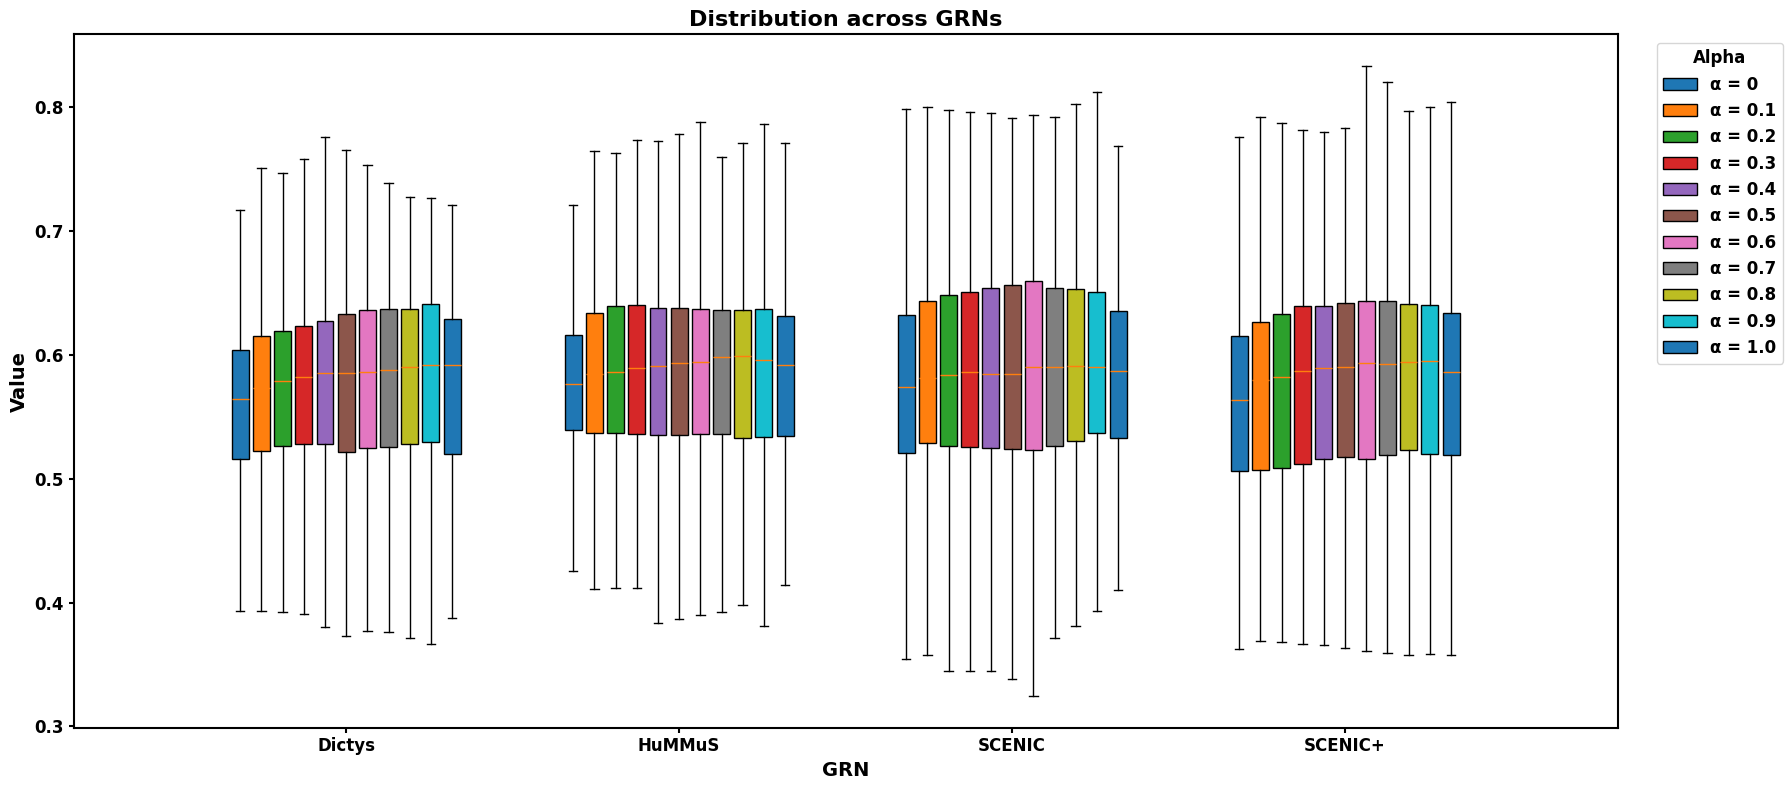

In [5]:
median_values_grn = plot_grn_distribution(grn_full_list)

### Scatter Plot 

In [6]:
result = median_values_grn.loc[
    median_values_grn.groupby("GRN")["Median values"].idxmax(),
    ["GRN", "Alpha", "Median values"]
].reset_index(drop=True)

In [19]:
median_values_grn["Median"] = median_values_grn["Median values"].apply(np.median)
median_values_grn["Mean"] = median_values_grn["Median values"].apply(np.mean)
df = median_values_grn[["Alpha", "GRN", "Median", "Mean"]]

/tmp/ipykernel_4076885/1910940311.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


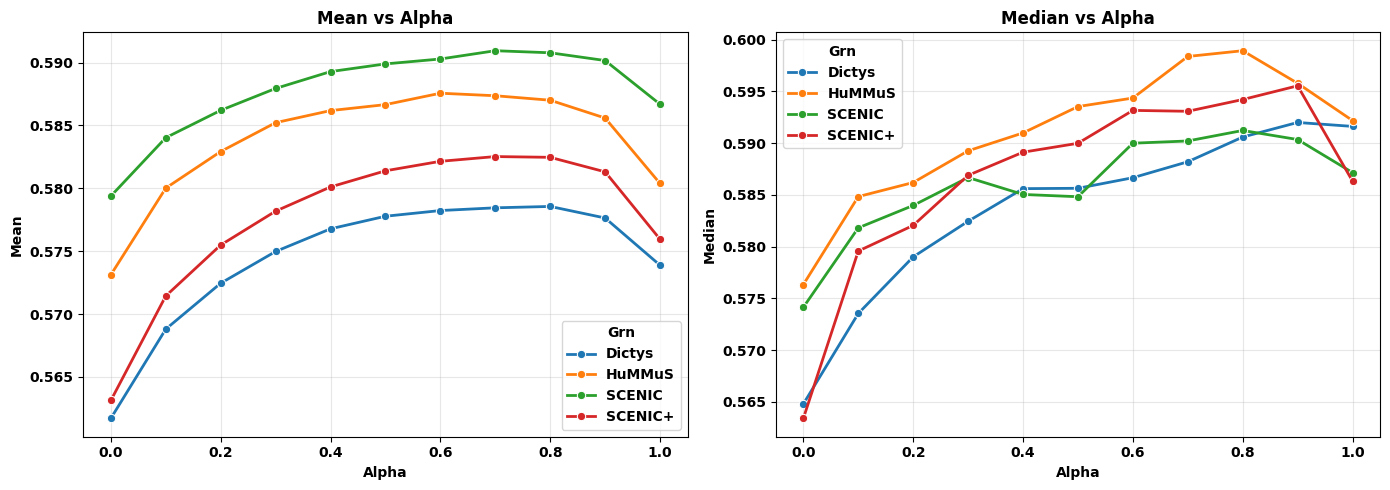

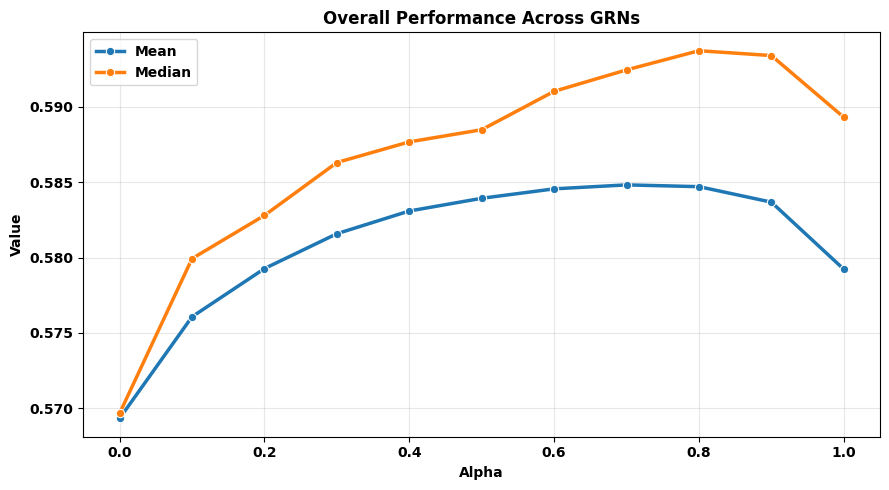

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Settings
# ============================================================

# Capitalize first letter of column names
df.columns = df.columns.str.capitalize()

# GRN name mapping
name_mapping = {
    "hummus": "HuMMuS",
    "scenic": "SCENIC",
    "scenic_plus": "SCENIC+",
    "dictys": "Dictys"
}

# Apply GRN name mapping
df["Grn"] = df["Grn"].map(name_mapping).fillna(df["Grn"])


# ============================================================
# 1. Mean and Median vs Alpha for each GRN
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -------------------------
# Mean vs Alpha
# -------------------------

sns.lineplot(
    data=df,
    x="Alpha",
    y="Mean",
    hue="Grn",
    marker="o",
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title("Mean vs Alpha", fontweight="bold")
axes[0].set_xlabel("Alpha", fontweight="bold")
axes[0].set_ylabel("Mean", fontweight="bold")
axes[0].grid(True, alpha=0.3)

# Make tick labels bold
for label in axes[0].get_xticklabels():
    label.set_fontweight("bold")

for label in axes[0].get_yticklabels():
    label.set_fontweight("bold")

# Make legend text bold
legend = axes[0].get_legend()
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_title().set_fontweight("bold")


# -------------------------
# Median vs Alpha
# -------------------------

sns.lineplot(
    data=df,
    x="Alpha",
    y="Median",
    hue="Grn",
    marker="o",
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title("Median vs Alpha", fontweight="bold")
axes[1].set_xlabel("Alpha", fontweight="bold")
axes[1].set_ylabel("Median", fontweight="bold")
axes[1].grid(True, alpha=0.3)

for label in axes[1].get_xticklabels():
    label.set_fontweight("bold")

for label in axes[1].get_yticklabels():
    label.set_fontweight("bold")

legend = axes[1].get_legend()
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_title().set_fontweight("bold")


plt.tight_layout()

# Save at 300 DPI
plt.savefig(
    "mean_median_vs_alpha.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 2. Overall Mean + Median Across GRNs
# ============================================================

summary = (
    df.groupby("Alpha")[["Mean", "Median"]]
      .mean()
      .reset_index()
)

plot_df = summary.melt(
    id_vars="Alpha",
    value_vars=["Mean", "Median"],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(9, 5))

sns.lineplot(
    data=plot_df,
    x="Alpha",
    y="Value",
    hue="Metric",
    marker="o",
    linewidth=2.5
)

plt.title(
    "Overall Performance Across GRNs",
    fontweight="bold"
)
plt.xlabel("Alpha", fontweight="bold")
plt.ylabel("Value", fontweight="bold")

plt.grid(True, alpha=0.3)

# Bold tick labels
plt.xticks(fontweight="bold")
plt.yticks(fontweight="bold")

# Bold legend
legend = plt.legend()
for text in legend.get_texts():
    text.set_fontweight("bold")
legend.get_title().set_fontweight("bold")

plt.tight_layout()

# Save at 300 DPI
plt.savefig(
    "overall_mean_median_vs_alpha.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()